In [1]:
!pip install opencv-python numpy matplotlib scikit-image scikit-learn medpy

Read dataset & preprocessing 


Found 4932 images in 'train' set.


Processing train:   0%|          | 0/4932 [00:00<?, ?it/s]

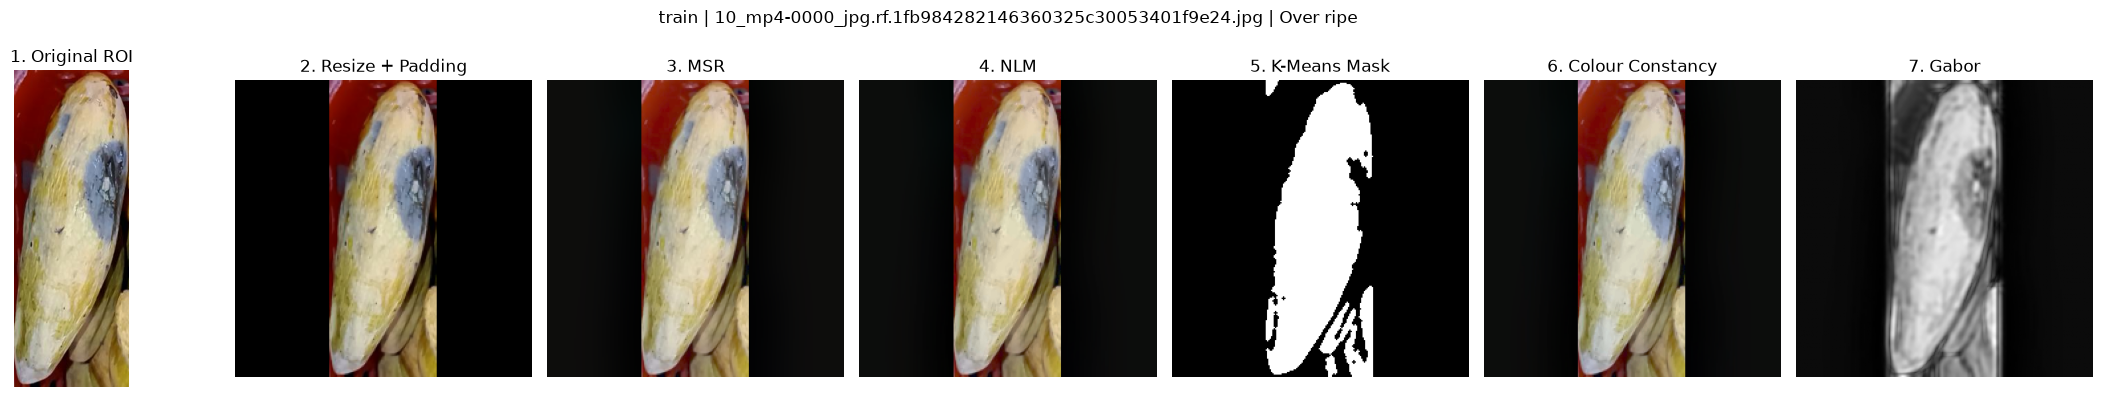

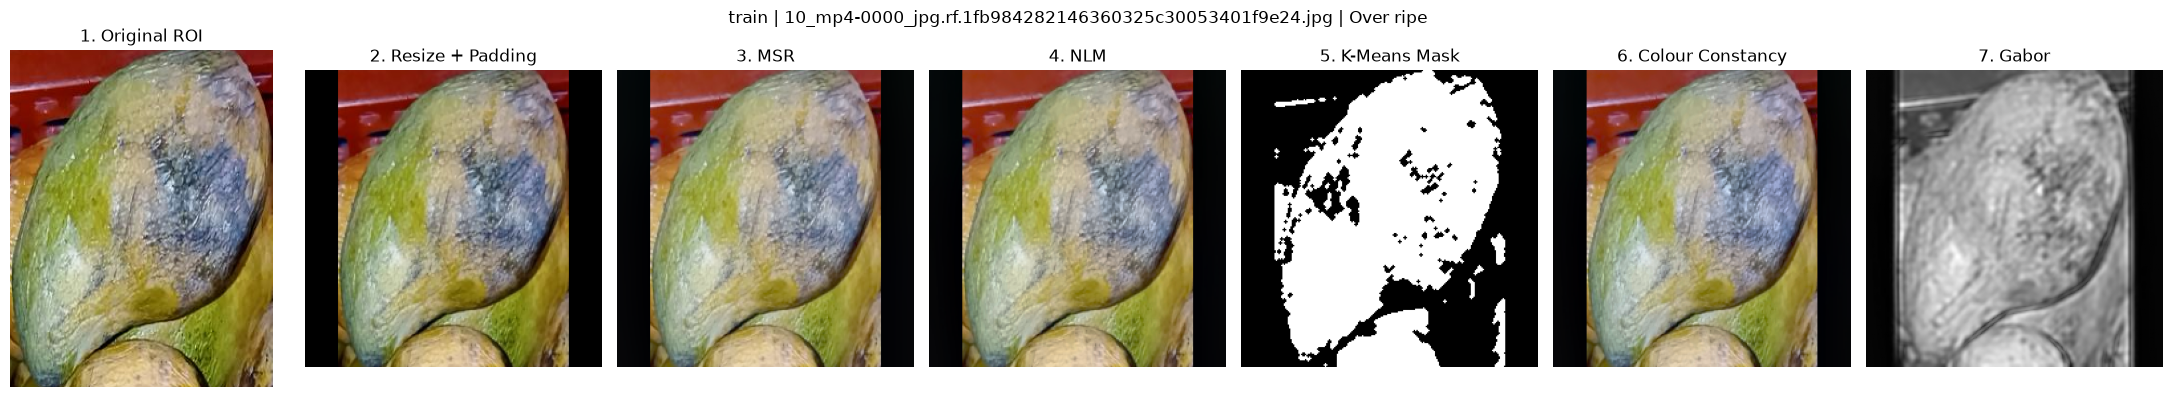

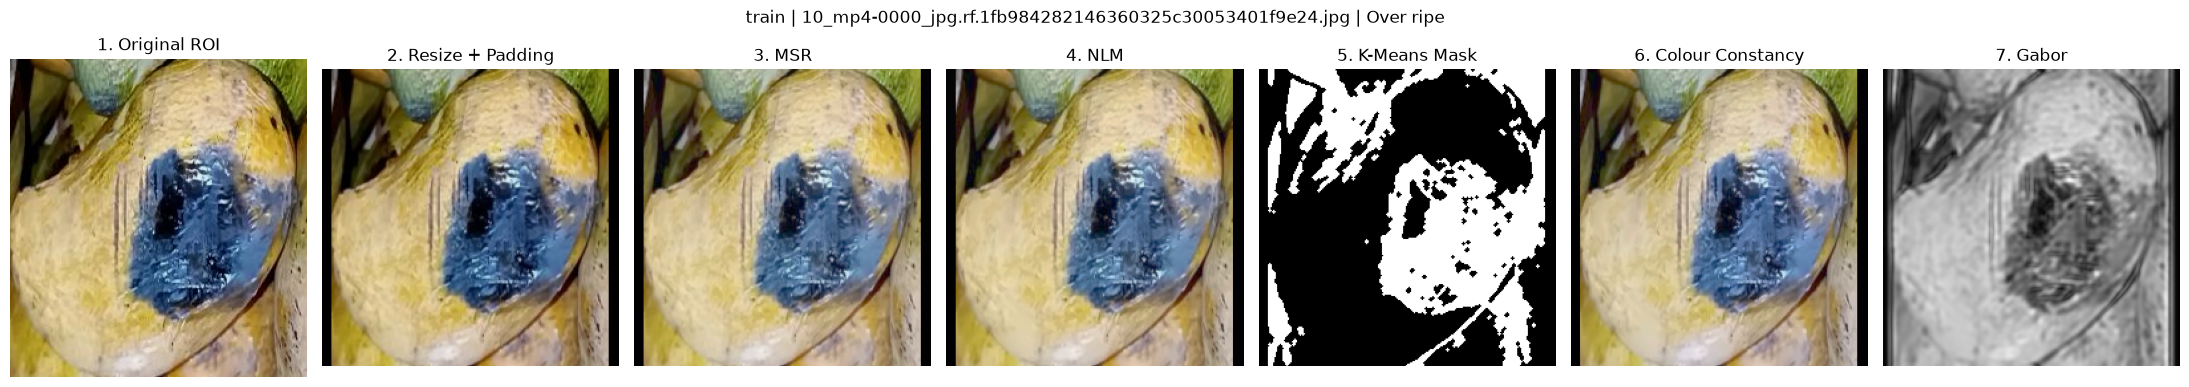

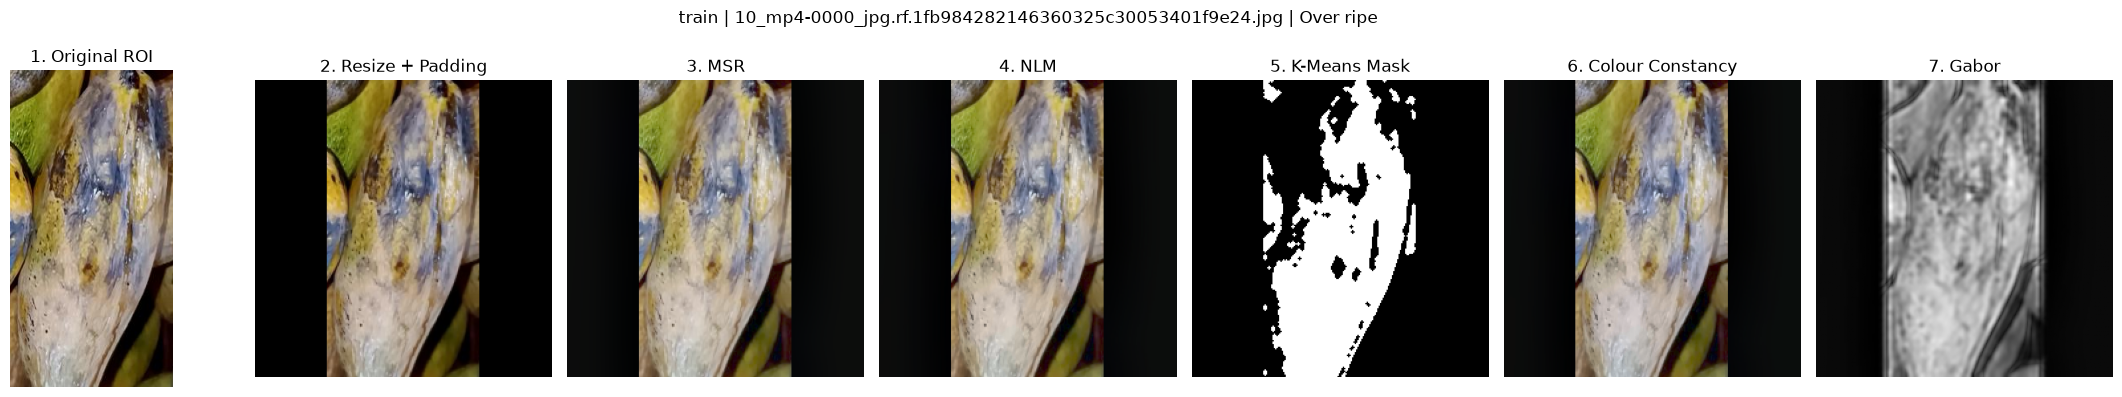

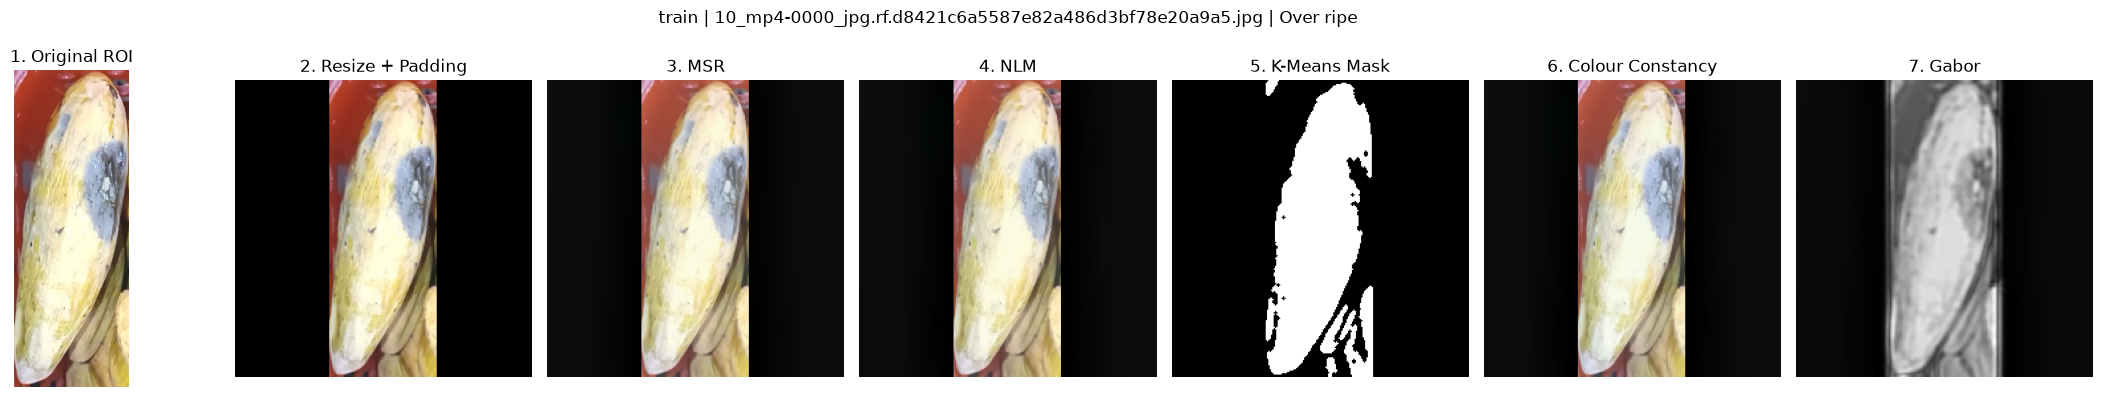


Found 453 images in 'valid' set.


Processing valid:   0%|          | 0/453 [00:00<?, ?it/s]


Found 228 images in 'test' set.


Processing test:   0%|          | 0/228 [00:00<?, ?it/s]


========== FINAL DATASET ==========
Training: (49255, 14) (49255,)
Validation: (4552, 14) (4552,)
Testing: (2358, 14) (2358,)

========== CLASS DISTRIBUTION ==========

Train: Counter({np.str_('Ripe'): 24894, np.str_('Unripe'): 14915, np.str_('Over ripe'): 9446})
Validation: Counter({np.str_('Ripe'): 2017, np.str_('Unripe'): 1663, np.str_('Over ripe'): 872})
Test: Counter({np.str_('Ripe'): 1111, np.str_('Unripe'): 834, np.str_('Over ripe'): 413})

Features per mango: 14


In [2]:
%matplotlib inline

import xml.etree.ElementTree as ET
from pathlib import Path
from collections import Counter

import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

from tqdm.notebook import tqdm


# =========================================================
# 1. PATH SETUP
# =========================================================

DATASET_PATH = Path("./MangoDataset")
SPLITS = ["train", "valid", "test"]


# =========================================================
# 2. RESIZE WITH ASPECT RATIO + PADDING
# =========================================================

def resize_with_padding(img, target_size=224):
    """
    Resize image while preserving aspect ratio.
    Padding is added instead of stretching the mango.
    """

    h, w = img.shape[:2]

    if h == 0 or w == 0:
        return None

    scale = min(target_size / w, target_size / h)

    new_w = max(1, int(w * scale))
    new_h = max(1, int(h * scale))

    interpolation = (
        cv.INTER_AREA
        if scale < 1
        else cv.INTER_CUBIC
    )

    resized = cv.resize(
        img,
        (new_w, new_h),
        interpolation=interpolation
    )

    canvas = np.zeros(
        (target_size, target_size, 3),
        dtype=np.uint8
    )

    x_offset = (target_size - new_w) // 2
    y_offset = (target_size - new_h) // 2

    canvas[
        y_offset:y_offset + new_h,
        x_offset:x_offset + new_w
    ] = resized

    return canvas


# =========================================================
# 3. MULTI-SCALE RETINEX (MSR)
# =========================================================

def illumination_correction(img_bgr):
    """
    Multi-Scale Retinex (MSR).

    Reduces uneven illumination using multiple
    Gaussian scales.
    """

    img = img_bgr.astype(np.float32) + 1.0

    sigma_list = [15, 80, 250]

    msr = np.zeros_like(
        img,
        dtype=np.float32
    )

    for sigma in sigma_list:

        blurred = cv.GaussianBlur(
            img,
            (0, 0),
            sigmaX=sigma,
            sigmaY=sigma
        )

        retinex = (
            np.log(img)
            - np.log(blurred + 1.0)
        )

        msr += retinex

    msr /= len(sigma_list)

    result = np.zeros_like(
        msr,
        dtype=np.float32
    )

    # Normalize each BGR channel independently
    for c in range(3):

        channel = msr[:, :, c]

        channel = cv.normalize(
            channel,
            None,
            0,
            255,
            cv.NORM_MINMAX
        )

        result[:, :, c] = channel

    result = np.clip(
        result,
        0,
        255
    ).astype(np.uint8)

    # Reduce the MSR strength to avoid an over-bright result.
    result = cv.addWeighted(
        result,
        0.2,
        img_bgr,
        0.8,
        0
    )

    return result


# =========================================================
# 4. NON-LOCAL MEANS (NLM) DENOISING
# =========================================================

def denoise_image(img_bgr):
    """
    Non-Local Means (NLM) denoising.

    Reduces image noise while preserving
    useful surface details.
    """

    return cv.fastNlMeansDenoisingColored(
        img_bgr,
        None,
        h=1,
        hColor=1,
        templateWindowSize=7,
        searchWindowSize=21
    )


# =========================================================
# 5. K-MEANS SEGMENTATION
# =========================================================

def create_mango_mask(img_bgr):
    """
    K-Means colour clustering segmentation.

    Since XML already provides the mango ROI,
    the mango is expected to occupy the centre
    region of the cropped image.
    """

    h, w = img_bgr.shape[:2]

    pixels = img_bgr.reshape(
        (-1, 3)
    ).astype(np.float32)

    criteria = (
        cv.TERM_CRITERIA_EPS
        + cv.TERM_CRITERIA_MAX_ITER,
        10,
        1.0
    )

    K = 3

    _, labels, centers = cv.kmeans(
        pixels,
        K,
        None,
        criteria,
        3,
        cv.KMEANS_PP_CENTERS
    )

    labels = labels.reshape(
        (h, w)
    )

    # =====================================================
    # Select cluster that dominates centre of ROI
    # =====================================================

    y1 = int(h * 0.25)
    y2 = int(h * 0.75)

    x1 = int(w * 0.25)
    x2 = int(w * 0.75)

    centre_labels = labels[
        y1:y2,
        x1:x2
    ].flatten()

    counts = np.bincount(
        centre_labels,
        minlength=K
    )

    mango_cluster = np.argmax(
        counts
    )

    binary_mask = (
        labels == mango_cluster
    ).astype(np.uint8)

    # =====================================================
    # MORPHOLOGICAL CLEANUP
    # =====================================================

    kernel = cv.getStructuringElement(
        cv.MORPH_ELLIPSE,
        (3, 3)
    )

    binary_mask = cv.morphologyEx(
        binary_mask,
        cv.MORPH_CLOSE,
        kernel
    )

    binary_mask = cv.morphologyEx(
        binary_mask,
        cv.MORPH_OPEN,
        kernel
    )

    # Same safety fallback concept
    if np.sum(binary_mask) < 50:

        binary_mask = np.ones(
            (h, w),
            dtype=np.uint8
        )

    return binary_mask


# =========================================================
# 6. COLOUR CONSTANCY
# =========================================================

def apply_colour_constancy(img_bgr):
    """
    Gray World Colour Constancy.

    Attempts to reduce colour cast caused
    by different illumination conditions.
    """

    img = img_bgr.astype(
        np.float32
    )

    b_mean = np.mean(
        img[:, :, 0]
    )

    g_mean = np.mean(
        img[:, :, 1]
    )

    r_mean = np.mean(
        img[:, :, 2]
    )

    gray_mean = (
        b_mean
        + g_mean
        + r_mean
    ) / 3.0

    eps = 1e-6

    img[:, :, 0] *= (
        gray_mean /
        (b_mean + eps)
    )

    img[:, :, 1] *= (
        gray_mean /
        (g_mean + eps)
    )

    img[:, :, 2] *= (
        gray_mean /
        (r_mean + eps)
    )

    corrected = np.clip(
        img,
        0,
        255
    ).astype(np.uint8)

    corrected = cv.addWeighted(
        corrected,
        0.25,
        img_bgr,
        0.75,
        0
    )

    return corrected


def extract_colour_constancy_features(
    img_bgr,
    mask
):
    """
    Extract colour features after
    Gray World Colour Constancy.

    Mean and standard deviation of
    each colour channel are used.
    """

    colour_corrected = (
        apply_colour_constancy(
            img_bgr
        )
    )

    valid = mask > 0

    if not np.any(valid):

        valid = np.ones_like(
            mask,
            dtype=bool
        )

    features = []

    for c in range(3):

        values = (
            colour_corrected[
                :, :, c
            ][valid]
        )

        features.extend([
            np.mean(values),
            np.std(values)
        ])

    features = np.array(
        features,
        dtype=np.float32
    )

    return (
        features,
        colour_corrected
    )


# =========================================================
# 7. GABOR FILTER TEXTURE FEATURES
# =========================================================

def extract_gabor_features(
    img_bgr,
    mask
):
    """
    Gabor Filter texture feature extraction.

    Multiple orientations are used to detect
    mango surface texture, spots and wrinkles.
    """

    gray = cv.cvtColor(
        img_bgr,
        cv.COLOR_BGR2GRAY
    )

    gray = gray.astype(
        np.float32
    )

    valid = mask > 0

    if not np.any(valid):

        valid = np.ones_like(
            mask,
            dtype=bool
        )

    features = []

    gabor_responses = []

    orientations = [
        0,
        np.pi / 4,
        np.pi / 2,
        3 * np.pi / 4
    ]

    for theta in orientations:

        kernel = cv.getGaborKernel(
            ksize=(15, 15),
            sigma=3.0,
            theta=theta,
            lambd=8.0,
            gamma=0.5,
            psi=0,
            ktype=cv.CV_32F
        )

        response = cv.filter2D(
            gray,
            cv.CV_32F,
            kernel
        )

        values = response[
            valid
        ]

        features.extend([
            np.mean(values),
            np.std(values)
        ])

        gabor_responses.append(
            np.abs(response)
        )

    features = np.array(
        features,
        dtype=np.float32
    )

    # Visualization image
    gabor_img = np.mean(
        gabor_responses,
        axis=0
    )

    gabor_img = cv.normalize(
        gabor_img,
        None,
        0,
        255,
        cv.NORM_MINMAX
    ).astype(np.uint8)

    return (
        features,
        gabor_img
    )


# =========================================================
# 8. COMBINED FEATURE EXTRACTION
# =========================================================

def extract_features(original_crop):
    """
    Siyu processing pipeline.

    1. Resize + Padding
    2. Multi-Scale Retinex
    3. Non-Local Means
    4. K-Means Segmentation
    5. Colour Constancy
    6. Gabor Filter
    """

    # =====================================================
    # RESIZE
    # =====================================================

    resized = resize_with_padding(
        original_crop,
        target_size=224
    )

    # =====================================================
    # MULTI-SCALE RETINEX
    # =====================================================

    corrected = illumination_correction(
        resized
    )

    # =====================================================
    # NON-LOCAL MEANS
    # =====================================================

    denoised = denoise_image(
        corrected
    )

    # =====================================================
    # K-MEANS SEGMENTATION
    # =====================================================

    mask = create_mango_mask(
        denoised
    )

    # =====================================================
    # COLOUR CONSTANCY
    # =====================================================

    (
        colour_features,
        colour_corrected

    ) = extract_colour_constancy_features(
        denoised,
        mask
    )

    # =====================================================
    # GABOR TEXTURE
    # =====================================================

    (
        gabor_features,
        gabor_img

    ) = extract_gabor_features(
        colour_corrected,
        mask
    )

    # =====================================================
    # COMBINE FEATURES
    # =====================================================

    combined = np.hstack([
        colour_features,
        gabor_features
    ])

    return (
        combined,
        resized,
        corrected,
        denoised,
        mask,
        colour_corrected,
        gabor_img
    )


# =========================================================
# 9. DATASET ARRAYS
# =========================================================

X_train, y_train = [], []
X_valid, y_valid = [], []
X_test, y_test = [], []


# =========================================================
# 10. READ DATASET
# =========================================================

display_count = 0

for split in SPLITS:

    folder = DATASET_PATH / split

    if not folder.exists():

        print(
            f"Skipping missing folder: {folder}"
        )

        continue

    image_files = list(
        folder.glob("*.jpg")
    )

    print(
        f"\nFound {len(image_files)} images "
        f"in '{split}' set."
    )

    for img_path in tqdm(
        image_files,
        desc=f"Processing {split}"
    ):

        img = cv.imread(
            str(img_path)
        )

        if img is None:
            continue

        xml_path = img_path.with_suffix(
            ".xml"
        )

        if not xml_path.exists():
            continue

        try:

            tree = ET.parse(
                xml_path
            )

            root = tree.getroot()

        except ET.ParseError:
            continue

        img_h, img_w = img.shape[:2]

        for obj in root.findall(
            "object"
        ):

            name_node = obj.find(
                "name"
            )

            b = obj.find(
                "bndbox"
            )

            if (
                name_node is None
                or b is None
            ):
                continue

            label = (
                name_node.text.strip()
            )

            try:

                xmin = int(float(
                    b.find("xmin").text
                ))

                ymin = int(float(
                    b.find("ymin").text
                ))

                xmax = int(float(
                    b.find("xmax").text
                ))

                ymax = int(float(
                    b.find("ymax").text
                ))

            except Exception:
                continue

            # =================================================
            # KEEP BOX INSIDE IMAGE
            # =================================================

            xmin = max(
                0,
                min(xmin, img_w - 1)
            )

            ymin = max(
                0,
                min(ymin, img_h - 1)
            )

            xmax = max(
                1,
                min(xmax, img_w)
            )

            ymax = max(
                1,
                min(ymax, img_h)
            )

            if (
                xmax <= xmin
                or ymax <= ymin
            ):
                continue

            crop = img[
                ymin:ymax,
                xmin:xmax
            ]

            if crop.size == 0:
                continue


            # =================================================
            # OPTIONAL QUALITY FILTER
            # =================================================

            crop_h, crop_w = crop.shape[:2]

            # Ignore extremely tiny mango ROI
            if crop_w < 10 or crop_h < 20:
                continue


            # =================================================
            # FEATURE EXTRACTION
            # =================================================

            (
                features,
                resized,
                corrected,
                denoised,
                mask,
                colour_corrected,
                gabor_img

            ) = extract_features(
                crop
            )


            # =================================================
            # APPEND DATA
            # =================================================

            if split == "train":

                X_train.append(
                    features
                )

                y_train.append(
                    label
                )

            elif split == "valid":

                X_valid.append(
                    features
                )

                y_valid.append(
                    label
                )

            elif split == "test":

                X_test.append(
                    features
                )

                y_test.append(
                    label
                )


            # =================================================
            # DISPLAY FIRST 5 EXAMPLES
            # =================================================

            if display_count < 5:

                fig, axes = plt.subplots(
                    1,
                    7,
                    figsize=(22, 4)
                )

                # ---------------------------------------------
                # 1. ORIGINAL ROI
                # ---------------------------------------------

                axes[0].imshow(
                    cv.cvtColor(
                        crop,
                        cv.COLOR_BGR2RGB
                    )
                )

                axes[0].set_title(
                    "1. Original ROI"
                )


                # ---------------------------------------------
                # 2. RESIZE + PADDING
                # ---------------------------------------------

                axes[1].imshow(
                    cv.cvtColor(
                        resized,
                        cv.COLOR_BGR2RGB
                    )
                )

                axes[1].set_title(
                    "2. Resize + Padding"
                )


                # ---------------------------------------------
                # 3. MULTI-SCALE RETINEX
                # ---------------------------------------------

                axes[2].imshow(
                    cv.cvtColor(
                        corrected,
                        cv.COLOR_BGR2RGB
                    )
                )

                axes[2].set_title(
                    "3. MSR"
                )


                # ---------------------------------------------
                # 4. NON-LOCAL MEANS
                # ---------------------------------------------

                axes[3].imshow(
                    cv.cvtColor(
                        denoised,
                        cv.COLOR_BGR2RGB
                    )
                )

                axes[3].set_title(
                    "4. NLM"
                )


                # ---------------------------------------------
                # 5. K-MEANS MASK
                # ---------------------------------------------

                axes[4].imshow(
                    mask,
                    cmap="gray"
                )

                axes[4].set_title(
                    "5. K-Means Mask"
                )


                # ---------------------------------------------
                # 6. COLOUR CONSTANCY
                # ---------------------------------------------

                axes[5].imshow(
                    cv.cvtColor(
                        colour_corrected,
                        cv.COLOR_BGR2RGB
                    )
                )

                axes[5].set_title(
                    "6. Colour Constancy"
                )


                # ---------------------------------------------
                # 7. GABOR FILTER
                # ---------------------------------------------

                axes[6].imshow(
                    gabor_img,
                    cmap="gray"
                )

                axes[6].set_title(
                    "7. Gabor"
                )


                for ax in axes:

                    ax.axis(
                        "off"
                    )

                fig.suptitle(
                    f"{split} | "
                    f"{img_path.name} | "
                    f"{label}"
                )

                plt.tight_layout()

                plt.show()

                display_count += 1


# =========================================================
# 11. CONVERT TO NUMPY
# =========================================================

X_train = np.array(
    X_train,
    dtype=np.float32
)

y_train = np.array(
    y_train
)

X_valid = np.array(
    X_valid,
    dtype=np.float32
)

y_valid = np.array(
    y_valid
)

X_test = np.array(
    X_test,
    dtype=np.float32
)

y_test = np.array(
    y_test
)


# =========================================================
# 12. DATASET SUMMARY
# =========================================================

print(
    "\n========== FINAL DATASET =========="
)

print(
    "Training:",
    X_train.shape,
    y_train.shape
)

print(
    "Validation:",
    X_valid.shape,
    y_valid.shape
)

print(
    "Testing:",
    X_test.shape,
    y_test.shape
)


print(
    "\n========== CLASS DISTRIBUTION =========="
)

print(
    "\nTrain:",
    Counter(y_train)
)

print(
    "Validation:",
    Counter(y_valid)
)

print(
    "Test:",
    Counter(y_test)
)


# =========================================================
# 13. FEATURE SIZE
# =========================================================

if len(X_train) > 0:

    print(
        "\nFeatures per mango:",
        X_train.shape[1]
    )

Train

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

# Train SVM
svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

train_pred = svm_model.predict(X_train_scaled)
valid_pred = svm_model.predict(X_valid_scaled)
test_pred = svm_model.predict(X_test_scaled)

print("Training Accuracy:", accuracy_score(y_train, train_pred))
print("Validation Accuracy:",accuracy_score(y_valid, valid_pred))
print("Testing Accuracy:", accuracy_score(y_test, test_pred))

Z:\anancoda\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Training Accuracy: 0.9739924880722769
Validation Accuracy: 0.9707820738137083
Testing Accuracy: 0.9758269720101781


In [4]:
from sklearn.metrics import classification_report

print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

   Over ripe       0.92      0.96      0.94       413
        Ripe       0.98      0.97      0.98      1111
      Unripe       1.00      0.99      0.99       834

    accuracy                           0.98      2358
   macro avg       0.97      0.97      0.97      2358
weighted avg       0.98      0.98      0.98      2358



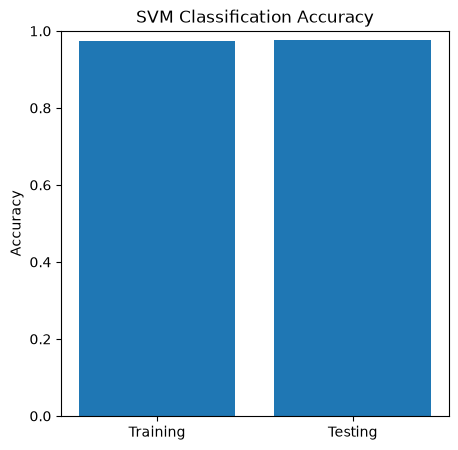

In [5]:
import matplotlib.pyplot as plt

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

plt.figure(figsize=(5,5))

plt.bar(
    ["Training", "Testing"],
    [train_acc, test_acc]
)

plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("SVM Classification Accuracy")

plt.show()

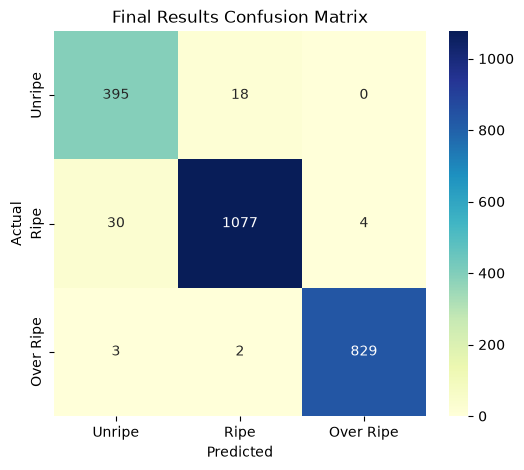

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, test_pred)
labels = ["Unripe", "Ripe", "Over Ripe"]

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Final Results Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [7]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
 
accuracy = accuracy_score(y_test, test_pred)
precision = precision_score(y_test, test_pred, average="weighted")
recall = recall_score(y_test, test_pred, average="weighted")
f1 = f1_score(y_test, test_pred, average="weighted")

print("----- Final Summary Metrics -----")
print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")

----- Final Summary Metrics -----
Accuracy : 0.976
Precision: 0.976
Recall   : 0.976
F1 Score : 0.976


WARNING Ultralytics settings updated to the latest schema. Existing values were preserved where possible. 
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\tansh\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
YOLO folder structure created.

Processing train: 4932 images
train: 4932 converted, 0 skipped.

Processing valid: 453 images
valid: 453 converted, 0 skipped.

Processing test: 228 images
test: 228 converted, 0 skipped.

XML to YOLO conversion completed.
train: 4932 images | 4932 labels
valid: 453 images | 453 labels
test: 228 images | 228 labels

Sample label file:
MangoYOLO\labels\train\10_mp4-0000_jpg.rf.1fb984282146360325c30053401f9e24.txt

Contents:
0 0.161719 0.564063 0.257812 0.706250
0 0.511719 0.360938 0.379688 0.487500
0 0.446094 0.739062 0.370312 0.396875
0 0.722656 0.716406 0.292187 0.567187


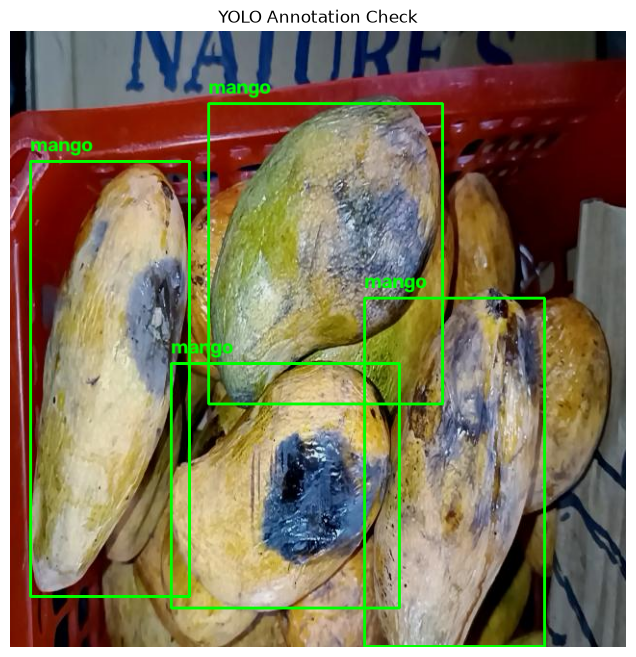


mango.yaml created successfully:

path: C:/Users/tansh/Downloads/MangoYOLO

train: images/train
val: images/valid
test: images/test

names:
  0: mango

YOLO base model loaded.
New https://pypi.org/project/ultralytics/8.4.141 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.137  Python-3.14.6 torch-2.13.0+cpu CPU (12th Gen Intel Core i7-12650H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=mango.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_

In [8]:
from pathlib import Path
import xml.etree.ElementTree as ET
import shutil
import os
import cv2 as cv
import matplotlib.pyplot as plt

from ultralytics import YOLO


SOURCE_DATASET = Path("./MangoDataset")
YOLO_DATASET = Path("./MangoYOLO")

splits = ["train", "valid", "test"]

for split in splits:

    (YOLO_DATASET / "images" / split).mkdir(
        parents=True,
        exist_ok=True
    )

    (YOLO_DATASET / "labels" / split).mkdir(
        parents=True,
        exist_ok=True
    )


print("YOLO folder structure created.")

def convert_xml_to_yolo(
    xml_path,
    image_width,
    image_height
):

    tree = ET.parse(xml_path)
    root = tree.getroot()

    yolo_labels = []

    for obj in root.findall("object"):

        bbox = obj.find("bndbox")

        if bbox is None:
            continue

        xmin = float(
            bbox.find("xmin").text
        )

        ymin = float(
            bbox.find("ymin").text
        )

        xmax = float(
            bbox.find("xmax").text
        )

        ymax = float(
            bbox.find("ymax").text
        )

        xmin = max(
            0,
            min(
                xmin,
                image_width
            )
        )

        xmax = max(
            0,
            min(
                xmax,
                image_width
            )
        )

        ymin = max(
            0,
            min(
                ymin,
                image_height
            )
        )

        ymax = max(
            0,
            min(
                ymax,
                image_height
            )
        )

        if xmax <= xmin or ymax <= ymin:
            continue

        x_center = (
            (xmin + xmax) / 2
        ) / image_width

        y_center = (
            (ymin + ymax) / 2
        ) / image_height

        box_width = (
            xmax - xmin
        ) / image_width

        box_height = (
            ymax - ymin
        ) / image_height


        class_id = 0


        yolo_labels.append(
            f"{class_id} "
            f"{x_center:.6f} "
            f"{y_center:.6f} "
            f"{box_width:.6f} "
            f"{box_height:.6f}"
        )
    return yolo_labels

for split in splits:

    source_folder = (
        SOURCE_DATASET / split
    )

    if not source_folder.exists():

        print(
            f"Skipping missing folder: "
            f"{source_folder}"
        )

        continue

    image_files = (
        list(
            source_folder.glob("*.jpg")
        )
        +
        list(
            source_folder.glob("*.jpeg")
        )
        +
        list(
            source_folder.glob("*.png")
        )
    )


    print(
        f"\nProcessing {split}: "
        f"{len(image_files)} images"
    )


    converted_count = 0
    skipped_count = 0


    for image_path in image_files:

        xml_path = image_path.with_suffix(
            ".xml"
        )

        if not xml_path.exists():

            print(
                f"Missing XML: "
                f"{image_path.name}"
            )

            skipped_count += 1

            continue

        image = cv.imread(
            str(image_path)
        )


        if image is None:

            print(
                f"Cannot read image: "
                f"{image_path.name}"
            )

            skipped_count += 1

            continue


        height, width = image.shape[:2]

        yolo_labels = convert_xml_to_yolo(
            xml_path,
            width,
            height
        )

        destination_image = (
            YOLO_DATASET
            / "images"
            / split
            / image_path.name
        )


        shutil.copy2(
            image_path,
            destination_image
        )

        destination_label = (
            YOLO_DATASET
            / "labels"
            / split
            / f"{image_path.stem}.txt"
        )


        with open(
            destination_label,
            "w"
        ) as f:

            f.write(
                "\n".join(
                    yolo_labels
                )
            )


        converted_count += 1


    print(
        f"{split}: "
        f"{converted_count} converted, "
        f"{skipped_count} skipped."
    )


print(
    "\nXML to YOLO conversion completed."
)

for split in splits:

    image_folder = (
        YOLO_DATASET
        / "images"
        / split
    )

    label_folder = (
        YOLO_DATASET
        / "labels"
        / split
    )


    image_count = len(
        list(
            image_folder.glob("*.*")
        )
    )

    label_count = len(
        list(
            label_folder.glob("*.txt")
        )
    )


    print(
        f"{split}: "
        f"{image_count} images | "
        f"{label_count} labels"
    )

sample_labels = list(
    (
        YOLO_DATASET
        / "labels"
        / "train"
    ).glob("*.txt")
)


if len(sample_labels) > 0:

    sample_label = sample_labels[0]

    print(
        "\nSample label file:"
    )

    print(
        sample_label
    )

    print(
        "\nContents:"
    )

    with open(
        sample_label,
        "r"
    ) as f:

        print(
            f.read()
        )

train_images = list(
    (
        YOLO_DATASET
        / "images"
        / "train"
    ).glob("*.jpg")
)


if len(train_images) > 0:

    sample_image_path = train_images[0]

    sample_label_path = (
        YOLO_DATASET
        / "labels"
        / "train"
        / f"{sample_image_path.stem}.txt"
    )


    image = cv.imread(
        str(
            sample_image_path
        )
    )


    height, width = image.shape[:2]


    if sample_label_path.exists():

        with open(
            sample_label_path,
            "r"
        ) as f:

            lines = f.readlines()


        for line in lines:

            values = line.strip().split()

            if len(values) != 5:
                continue


            class_id = int(
                values[0]
            )

            x_center = float(
                values[1]
            )

            y_center = float(
                values[2]
            )

            box_width = float(
                values[3]
            )

            box_height = float(
                values[4]
            )


            # Convert YOLO back
            # into pixel coordinates
            x_center *= width
            y_center *= height

            box_width *= width
            box_height *= height


            xmin = int(
                x_center
                -
                box_width / 2
            )

            ymin = int(
                y_center
                -
                box_height / 2
            )

            xmax = int(
                x_center
                +
                box_width / 2
            )

            ymax = int(
                y_center
                +
                box_height / 2
            )


            cv.rectangle(
                image,
                (xmin, ymin),
                (xmax, ymax),
                (0, 255, 0),
                2
            )


            cv.putText(
                image,
                "mango",
                (
                    xmin,
                    max(
                        ymin - 10,
                        20
                    )
                ),
                cv.FONT_HERSHEY_SIMPLEX,
                0.7,
                (0, 255, 0),
                2
            )


    plt.figure(
        figsize=(10, 8)
    )

    plt.imshow(
        cv.cvtColor(
            image,
            cv.COLOR_BGR2RGB
        )
    )

    plt.title(
        "YOLO Annotation Check"
    )

    plt.axis(
        "off"
    )

    plt.show()

dataset_root = (
    YOLO_DATASET.resolve()
)


yaml_content = f"""
path: {dataset_root.as_posix()}

train: images/train
val: images/valid
test: images/test

names:
  0: mango
"""


with open(
    "mango.yaml",
    "w"
) as f:

    f.write(
        yaml_content
    )


print(
    "\nmango.yaml created successfully:"
)

print(
    yaml_content
)

detector = YOLO(
    "yolov8n.pt"
)


print(
    "YOLO base model loaded."
)

training_results = detector.train(

    data="mango.yaml",

    epochs=50,

    imgsz=640,

    batch=8,

    project="mango_yolo_runs",

    name="mango_detector"
)


print(
    "YOLO training completed."
)

best_model_path = Path(
    r"C:\Users\User\anaconda_projects\Assignment\runs\detect\mango_yolo_runs\mango_detector\weights\best.pt"
)

if best_model_path.exists():

    best_model = YOLO(
        str(
            best_model_path
        )
    )

    print(
        "Best YOLO detector loaded:"
    )

    print(
        best_model_path
    )

else:

    print(
        "best.pt not found."
    )

test_images = (
    list(
        (
            YOLO_DATASET
            / "images"
            / "test"
        ).glob("*.jpg")
    )
    +
    list(
        (
            YOLO_DATASET
            / "images"
            / "test"
        ).glob("*.jpeg")
    )
    +
    list(
        (
            YOLO_DATASET
            / "images"
            / "test"
        ).glob("*.png")
    )
)


if (
    best_model_path.exists()
    and len(test_images) > 0
):

    test_image_path = (
        test_images[0]
    )


    results = best_model.predict(

        source=str(
            test_image_path
        ),

        conf=0.5,

        save=False
    )


    plotted_image = (
        results[0].plot()
    )


    plt.figure(
        figsize=(10, 8)
    )

    plt.imshow(
        cv.cvtColor(
            plotted_image,
            cv.COLOR_BGR2RGB
        )
    )

    plt.title(
        "YOLO Mango Detection Result"
    )

    plt.axis(
        "off"
    )

    plt.show()

if best_model_path.exists():

    destination_model = Path(
        "mango_detector.pt"
    )


    shutil.copy2(
        best_model_path,
        destination_model
    )


    print(
        "\nMango detector saved as:"
    )

    print(
        destination_model.resolve()
    )

else:

    print(
        "Unable to create mango_detector.pt "
        "because best.pt was not found."
    )